# Patient figures
Cleaned: live cells only (dead iterations removed). Cohort 10 LH / 12 RH (sub-076 corrected).


## Patient table

In [19]:
import pandas as pd
# Public patient table — n=25 cohort (13 LH-intact / 12 RH-intact).
# P-codes: LH-intact P01-P13, RH-intact P14-P25, each in ascending scan-age order.
# Surgery categories: "Hemi" (hemispherectomy/hemispherotomy/functional) | "OTC" (OTC resection).
# Site column dropped — operative notes use lobar language that doesn't map cleanly onto OTC.
# No sub_bids (kept in gitignored key).
_rows = [
    ("P01","F","Hemi","Left"),
    ("P02","M","OTC","Left"),
    ("P03","F","OTC","Left"),
    ("P04","F","Hemi","Left"),
    ("P05","F","Hemi","Left"),
    ("P06","F","Hemi","Left"),
    ("P07","M","OTC","Left"),
    ("P08","F","OTC","Left"),
    ("P09","M","Hemi","Left"),
    ("P10","M","OTC","Left"),
    ("P11","F","Hemi","Left"),
    ("P12","M","OTC","Left"),
    ("P13","M","Hemi","Left"),
    ("P14","M","Hemi","Right"),
    ("P15","F","Hemi","Right"),
    ("P16","M","OTC","Right"),
    ("P17","M","Hemi","Right"),
    ("P18","F","OTC","Right"),
    ("P19","F","Hemi","Right"),
    ("P20","M","OTC","Right"),
    ("P21","F","Hemi","Right"),
    ("P22","M","Hemi","Right"),
    ("P23","F","Hemi","Right"),
    ("P24","M","OTC","Right"),
    ("P25","F","OTC","Right"),
]
patient_table = pd.DataFrame(_rows, columns=["Patient","Sex","Surgery","Intact"])
assert len(patient_table) == 25
assert (patient_table["Intact"] == "Left").sum() == 13
assert (patient_table["Intact"] == "Right").sum() == 12
with pd.option_context("display.max_colwidth", None):
    display(patient_table)

,Patient,Sex,Surgery,Intact
0,P01,F,Hemi,Left
1,P02,M,OTC,Left
2,P03,F,OTC,Left
3,P04,F,Hemi,Left
4,P05,F,Hemi,Left
5,P06,F,Hemi,Left
6,P07,M,OTC,Left
7,P08,F,OTC,Left
8,P09,M,Hemi,Left
9,P10,M,OTC,Left


## Figure 1 — Cross-sectional (timeline + table + age strip + surgery type)

controls: 38 -> 36 after age cap <= 23


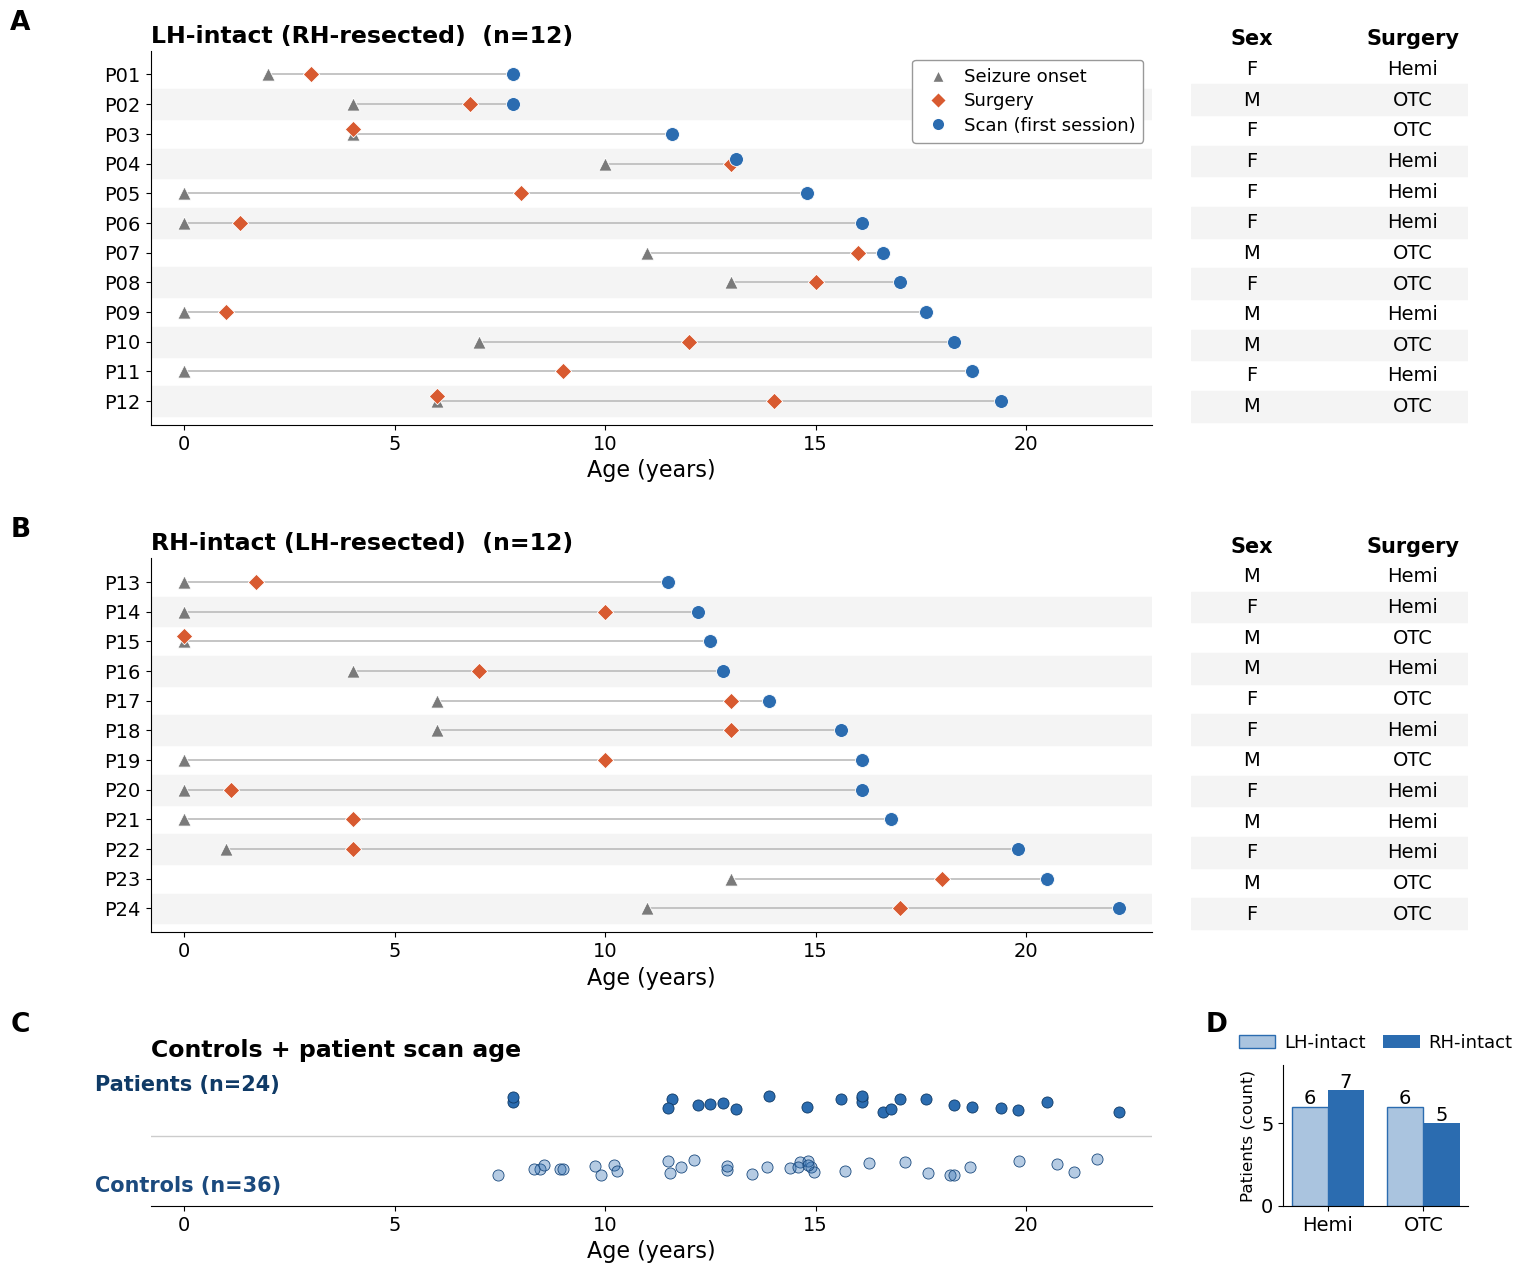

In [2]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip)
  D  Surgery type by hemisphere

AGE CAP <= 23 applied. Removes P13 (scan 37.3, = sub-091) and controls
sub-095 (38.5) and sub-096 (27.9). Those three were the only reason for the
37y axis break, so the break axes (axLb/axRb/axSb), the split() helper and the
diagonal break marks are gone. Cohort is now 12 LH-intact / 12 RH-intact and
34 controls.
"""

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

CSV = "/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"
CTRL_EXCLUDE = {"sub-027","sub-084"}
AGE_CAP = 23.0

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"
C_EDGE_P= "#0F3A66"
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
C_LH_BAR = (0.169, 0.424, 0.690, 0.40)   # translucent C_SCAN
AGE_MAX = 23
rng = np.random.default_rng(7)

# (pid, sex, surgery, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemi",  2.0,  3.0,   7.8),
    ("P02","M","OTC",   4.0,  6.8,   7.8),   # = sub-004 (UD in Liu 2025); surgery 6y9m
    ("P03","F","OTC",   4.0,  4.0,  11.6),
    ("P04","F","Hemi", 10.0, 13.0,  13.1),
    ("P05","F","Hemi",  0.0,  8.0,  14.8),
    ("P06","F","Hemi",  0.0,  1.33, 16.11),
    ("P07","M","OTC",  11.0, 16.0,  16.6),
    ("P08","F","OTC",  13.0, 15.0,  17.0),
    ("P09","M","Hemi",  0.0,  1.0,  17.62),
    ("P10","M","OTC",   7.0, 12.0,  18.3),
    ("P11","F","Hemi",  0.0,  9.0,  18.71),
    ("P12","M","OTC",   6.0,(6.0,14.0),19.4),
]
RH = [
    ("P13","M","Hemi",  0.0,  1.7, 11.5),
    ("P14","F","Hemi",  0.0, 10.0, 12.2),
    ("P15","M","OTC",   0.0,  0.0, 12.5),
    ("P16","M","Hemi",  4.0,  7.0, 12.8),
    ("P17","F","OTC",   6.0, 13.0, 13.9),
    ("P18","F","Hemi",  6.0, 13.0, 15.6),
    ("P19","M","OTC",   0.0, 10.0, 16.1),
    ("P20","F","Hemi",  0.0,  1.1, 16.1),
    ("P21","M","Hemi",  0.0,  4.0, 16.8),
    ("P22","F","Hemi",  1.0,  4.0, 19.8),
    ("P23","M","OTC",  13.0, 18.0, 20.5),
    ("P24","F","OTC",  11.0, 17.0, 22.2),
]
assert len(LH) == 12
assert len(RH) == 12
PT_SCAN = np.array([r[5] for r in LH+RH])
assert PT_SCAN.max() <= AGE_CAP, "a patient is above the age cap"

# The plotted scan must follow at least one surgery. Patients with more than
# one operation (surgery_age given as a tuple) can legitimately have a later
# surgery after the scan, so the check is against the EARLIEST surgery.
_su = lambda v: [x for x in (list(v) if isinstance(v,(tuple,list)) else [v])
                 if x is not None]
_bad = [(r[0], _su(r[4]), r[5]) for r in LH+RH if min(_su(r[4])) > r[5]]
if _bad:
    print("WARNING scan precedes all recorded surgeries:",
          ", ".join(f"{p} surgery {s} > scan {c}" for p,s,c in _bad))
COLX = {"Sex":0.22, "Surgery":0.80}

FS_TICK=14; FS_CELL=14; FS_HEADER=15; FS_TITLE=17; FS_XLAB=16; FS_NLAB=15
FS_LETTER=19; FS_LEGEND=13; FS_DLAB=15


def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)


def panel_letter(ax, L, dx=-0.12, dy=1.04):
    ax.text(dx, dy, L, transform=ax.transAxes, fontsize=FS_LETTER, fontweight="bold",
            va="bottom", ha="right")


def draw_timeline(ax, rows):
    """One row per patient. Events at the same age are offset vertically so
    seizure onset, surgery and scan do not overlap."""
    n=len(rows); bands(ax,n)
    JIT, WIN = 0.16, 0.6          # vertical offset; collision window in years
    for i,row in enumerate(rows):
        pid,_,_,sz,su,sc=row; y=n-1-i
        su_list=[v for v in (list(su) if isinstance(su,(tuple,list)) else [su])
                 if v is not None]
        ax.plot([min([sz]+su_list+[sc]), max([sz]+su_list+[sc])],[y,y],
                color=LINE,lw=1.2,zorder=1)
        ev = ([(sz,"^",90,C_SEIZ)]
              + [(sv,"D",70,C_SURG) for sv in su_list]
              + [(sc,"o",100,C_SCAN)])
        seen=[]
        for age,mk,ms,col in ev:
            k=sum(1 for a in seen if abs(a-age) < WIN); seen.append(age)
            dy = 0 if k==0 else (JIT if k % 2 else -JIT) * ((k+1)//2)
            ax.scatter(age, y+dy, marker=mk, s=ms, color=col, zorder=3,
                       edgecolors="white", linewidths=.6)
    ax.set_yticks(range(n)); ax.set_yticklabels([r[0] for r in reversed(rows)],fontsize=FS_TICK)
    ax.set_ylim(-0.8,n-0.2); ax.set_xlim(-0.8,AGE_MAX)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        sex,surg=row[1],row[2]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="center",va="center",fontsize=FS_CELL)
        ax.text(COLX["Surgery"],y,surg,ha="center",va="center",fontsize=FS_CELL)
    if header:
        for label,x in COLX.items():
            ax.text(x,n-0.35,label,ha="center",va="bottom",fontsize=FS_HEADER,
                    fontweight="bold",clip_on=False)


def draw_strip(ax):
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    n_before=len(ctrl)
    ctrl=ctrl[ctrl["age"]<=AGE_CAP]
    print(f'controls: {n_before} -> {len(ctrl)} after age cap <= {AGE_CAP:.0f}')
    cage=ctrl["age"].values
    ax.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    ax.scatter(PT_SCAN,0.45+rng.uniform(-.12,.12,len(PT_SCAN)),s=64,color=C_SCAN,
               edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    ax.scatter(cage,-0.45+rng.uniform(-.12,.12,len(cage)),s=64,
               facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,
               linewidths=.6,zorder=3)
    ax.set_xlim(-0.8,AGE_MAX); ax.set_ylim(-1,1); ax.set_yticks([])
    ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlabel("Age (years)",fontsize=FS_XLAB)
    ax.text(-0.055,.82,"Patients (n=" + str(len(PT_SCAN)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_P,fontweight="bold")
    ax.text(-0.055,.10,"Controls (n=" + str(len(cage)) + ")",transform=ax.transAxes,
            fontsize=FS_NLAB,color=C_EDGE_C,fontweight="bold")


def draw_surgtype(ax):
    cats=["Hemi","OTC"]
    lh_c=[sum(r[2]==c for r in LH) for c in cats]
    rh_c=[sum(r[2]==c for r in RH) for c in cats]
    x=np.arange(len(cats)); w=0.38
    ax.bar(x-w/2,lh_c,w,label="LH-intact",color=C_LH_BAR,edgecolor=C_SCAN,linewidth=1.0)
    ax.bar(x+w/2,rh_c,w,label="RH-intact",color=C_SCAN)
    for xi,(a,b) in enumerate(zip(lh_c,rh_c)):
        ax.text(xi-w/2,a+0.15,a,ha="center",fontsize=FS_CELL)
        ax.text(xi+w/2,b+0.15,b,ha="center",fontsize=FS_CELL)
    ax.set_xticks(x); ax.set_xticklabels(cats,fontsize=FS_DLAB)
    ax.set_ylabel("Patients (count)",fontsize=FS_DLAB-3)
    ax.set_ylim(0, max(max(lh_c),max(rh_c))+1.5)
    ax.legend(fontsize=FS_LEGEND,frameon=False,loc="lower center",
              bbox_to_anchor=(0.5,0.98),ncol=2,columnspacing=1.0,handletextpad=0.5)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK)


fig=plt.figure(figsize=(17,15))
gs=gridspec.GridSpec(3,2,width_ratios=[13,3.6],
                     height_ratios=[len(LH),len(RH),4.5],wspace=0.06,hspace=0.45)

axLm,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1])
draw_timeline(axLm,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=" + str(len(LH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axLm,"A")
axLm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axRm,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1])
draw_timeline(axRm,RH); draw_table(axRt,RH,header=True)
axRm.set_title("RH-intact (LH-resected)  (n=" + str(len(RH)) + ")",
               fontsize=FS_TITLE,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=FS_XLAB)

axSm=fig.add_subplot(gs[2,0])
draw_strip(axSm)
axSm.set_title("Controls + patient scan age",fontsize=FS_TITLE,fontweight="bold",loc="left")
panel_letter(axSm,"C",dy=1.20)

ndg=gs[2,1].subgridspec(1,2,width_ratios=[4.0,8],wspace=0)
axD=fig.add_subplot(ndg[0,1]); draw_surgtype(axD)
panel_letter(axD,"D",dx=-0.30,dy=1.20)

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=10,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=9,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=10,label="Scan (first session)"),
]
axLm.legend(handles=handles, loc="upper right", ncol=1, fontsize=FS_LEGEND,
            frameon=True, edgecolor="#999999", framealpha=1.0,
            borderpad=0.45, labelspacing=0.35, handletextpad=0.4, markerscale=0.9)

## Figure 2 — Representative anatomy

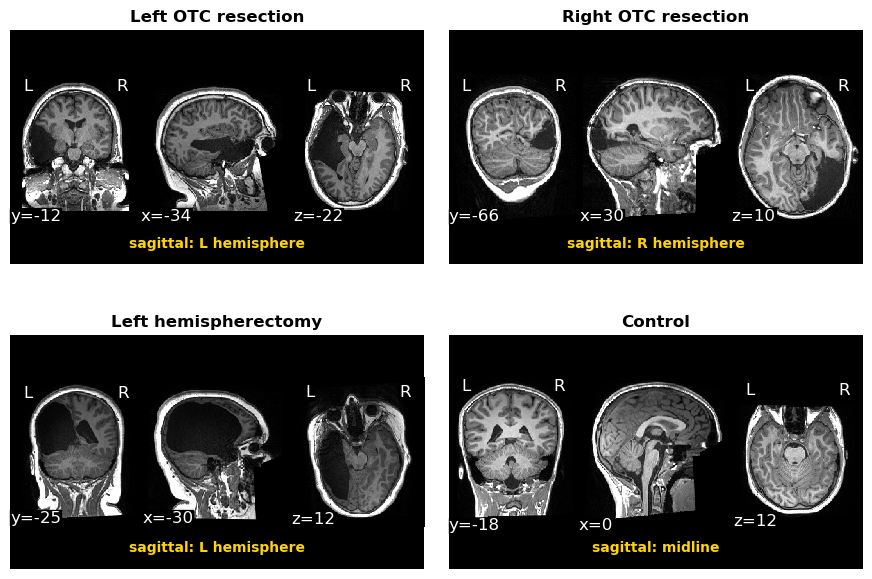

In [5]:
#!/usr/bin/env python
"""
Representative anatomy figure: one exemplar per surgery type + one control = 4 panels (2x2).
RUN ON THE CLUSTER. Cut coords are starting guesses — tune against each scan.
Heads equalized by tight head-bbox crop (world coords preserved). Sagittal (middle)
view labeled with its hemisphere (from cut x-sign).
"""
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"     # adjust if T1s live elsewhere
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
DIM = -1.25

# (row, col, sub, title two-line, (x,y,z) cut)
PANELS = [
    (0,0,"sub-044","Left OTC resection",   (-34,-12,-22)),
    (0,1,"sub-004","Right OTC resection",  ( 30,-66, 10)),
    (1,0,"sub-099","Left hemispherectomy", (-30,-25, 12)),
    (1,1,"sub-094","Control",              (  0,-18, 12)),
]

MARGIN = {"sub-044": 20}   # zero-background frame (voxels); larger = smaller head

def tight_crop(img, margin=6, frac=0.12):
    """Crop to head bbox, then add `margin` voxels of real zero-background on every
    side so the head occupies less of the FOV. World coords preserved."""
    d = img.get_fdata()
    thr = frac * np.percentile(d, 99.5)
    mask = d > thr
    if mask.sum() == 0: return img
    idx = np.array(np.where(mask))
    lo = idx.min(1); hi = idx.max(1) + 1
    sl = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    d = np.pad(d[sl], margin, mode="constant")
    aff = img.affine.copy()
    aff[:3, 3] = aff[:3, 3] + aff[:3, :3].dot(lo - margin)
    return nib.Nifti1Image(d, aff)

def show(ax, sub, title, cut):
    path = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{title}\n(T1 not found)",ha="center",va="center",fontsize=9); ax.axis("off"); return
    anat = tight_crop(image.load_img(path), margin=MARGIN.get(sub, 6))
    plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax, annotate=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    sag = "midline" if abs(cut[0]) < 5 else ("R hemisphere" if cut[0] > 0 else "L hemisphere")
    ax.text(0.5, 0.06, f"sagittal: {sag}", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#FFD400")

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.06)
for r, c, sub, title, cut in PANELS:
    show(fig.add_subplot(gs[r, c]), sub, title, cut)